# Introduction to NumPy

*Author: Evan Carey, written for BH Analytics*

## Overview

The purpose of this section is to demonstrate functionality of Python that you will be learning in this course. We will be covering the following:


* ndArray object type
* dtypes
* slicing
* broadcasting
* summary statistics
* random number generation

## Libraries

In [1]:
import sys
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
import textwrap

In [2]:
## Enable inline plotting for graphics
%matplotlib inline

In [3]:
## Get Version information
print(textwrap.fill(sys.version),'\n')
print("Pandas version: {0}".format(pd.__version__),'\n')
print("Matplotlib version: {0}".format(matplotlib.__version__),'\n')
print("Numpy version: {0}".format(np.__version__),'\n')
print("Seaborn version: {0}".format(sns.__version__),'\n')


3.7.10 (default, Feb 26 2021, 13:06:18) [MSC v.1916 64 bit (AMD64)] 

Pandas version: 1.2.4 

Matplotlib version: 3.3.4 

Numpy version: 1.20.1 

Seaborn version: 0.11.1 



## What is NumPy?

Numerical Python


* “Foundational” module for scientific computing
* Mimics matlab interface
* Provides the “ndarray”
* This is the way linear algebra is accomplished in Python.
* This is the main class for scientific computing
* Has a “dtype” attribute
* We will briefly cover this, but the analytic focus will be on Pandas structures and constructs

## Setting Print Options

We can set the print options for numpy like so:

In [4]:
np.set_printoptions(linewidth=90)

## Ndarray

* It is customary to import NumPy as “np”
* The fundamental data structure in numpy is the Ndarray. 
  * N-dimensional array (also called 'array')
  * Created with `array()` 
  * Can be more than one dimension
  * These are homogeneous (all one data type)

In [5]:
import numpy as np

# Create an array from a range generator
ar1 = np.array(range(10))
print(ar1)
print(ar1.ndim)

[0 1 2 3 4 5 6 7 8 9]
1


In [6]:
# Create an array from a list with 'implied structure'
ar2 = \
    np.array([[1,2,3],
              [4,5,6]])
print(ar2)

[[1 2 3]
 [4 5 6]]


In [7]:
# This array has 2 dimensions
print(ar2.ndim)

2


In [8]:
# the .shape method gives us deach dimensions length
print(ar2.shape)

(2, 3)


In [9]:
# The dtype (data type) method of the array 
print(ar2.dtype)

int32


There are several other functions to create convenient arrays. Below are examples:

* `arange()`
* `ones()`	    create an array of all ones
* `zeros()`     create an array of all zeros
* `identity()`	create an identity matrix


In [10]:
# More array creation
print('Example 1:\n',
      np.ones((2,4)))
print('\n\n')
print('Example 2:\n',
      np.zeros((2,4)))
print('\n\n')
print('Example 3:\n',
      np.identity(5))


Example 1:
 [[1. 1. 1. 1.]
 [1. 1. 1. 1.]]



Example 2:
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]]



Example 3:
 [[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]


In [11]:
np.eye(3) # another convenience function for an identity matrix

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

## Attributes

We can explore the attributes of NumPy arrays using the following syntax.

`ndim`: number of dimensions  
`shape`: list of the dimension lengths  
`size`: total number of elements  
`data`: elements of the array  
`dtype`: data type (beyond standard Python date types)


In [12]:
# Attributes
print(ar1.ndim)

1


In [13]:
print(ar2.ndim)

2


In [14]:
print(ar2.shape)

(2, 3)


In [15]:
print(ar2.dtype)

int32


In [16]:
print(ar2.size)

6


## Data Types

Arrays are fast, partially due to the data type mapping to lower level calls. The dtype is inferred when we create an array, but we can specify the dtype as well
  
* `np.array(object[,dtype])`
* We can change type using `array.astype()`


In [17]:
# Dtype specification
ar3 = np.array([1,2,3,4,5,6],"float")
print(ar3.dtype)

float64


In [18]:
# change dtype (type casting)
ar3 = ar3.astype("int")
print(ar3.dtype)

int32


In [19]:
# Boolean dtype:
print(np.array([True,False],"bool").dtype)

bool


Strings look odd at first. The base Python string literal is converted to a unicode data type. The resulting dtype includes the byte order 'endiness' indicator (< or >), the `U` for unicode, and the length (3 in this case). 

In [20]:
# string literal dtype
print(np.array(["Yes","No"]).dtype)

<U3


In [21]:
print(np.array(["Yes","No"],str).dtype)

<U3


More information here:   
https://jakevdp.github.io/PythonDataScienceHandbook/02.01-understanding-data-types.html#NumPy-Standard-Data-Types
  
and here:  
https://docs.scipy.org/doc/numpy-1.9.3/reference/arrays.dtypes.html

## Indexing

* For one dimensional arrays, we index in the usual way
* These slices are views, not copies…
* Since they are view, we can request changes that will be *broadcasted* if need be
* Indexing is **end-exclusive**  (like normal Python)


Here are some examples of slicing:

In [22]:
# Indexing (slicing)
line = np.arange(1,4*4*4+1)
print('Initial line ndarray:\n',
      line)

Initial line ndarray:
 [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29
 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58
 59 60 61 62 63 64]


In [23]:
print('\nFirst element:',
      line[0])


First element: 1


In [24]:
print('Elements 1 through 4 but not including 5:',
      line[:4])

Elements 1 through 4 but not including 5: [1 2 3 4]


In [25]:
print('Last element to 9th from last element:',
      line[-1:-10:-1])

Last element to 9th from last element: [64 63 62 61 60 59 58 57 56]


Notice if we pass in a list with repeated integers, we will select the same element multiple times:

In [26]:
print('Elements 2, 3, 2:',
      line[[1,2,1]])

Elements 2, 3, 2: [2 3 2]


And finally here is the broadcast behaviour mentioned earlier:

In [27]:
# broadcast a change
line[:3] = 2
line

array([ 2,  2,  2,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20,
       21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40,
       41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60,
       61, 62, 63, 64])

## Reshaping

If we need to change the shape of the array, we can reshape an array with `array.reshape()`. We often do this after creating an array if we want a specific shape/size. 

In [28]:
# Reshaping array
line = np.arange(1,4*4*4+1)
print('Original array:\n', line)

Original array:
 [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29
 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58
 59 60 61 62 63 64]


In [29]:
rectangle= line.reshape(4,16)
print('4x16 rectangular reshape:\n', rectangle)

4x16 rectangular reshape:
 [[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
 [17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32]
 [33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48]
 [49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64]]


## Multi-Dimensional Index

Indexing gets more interesting with multiple dimensions

* Start with first axis, separate by commas. 
* You can omit 'trailing' the axis, but that is bad coding form. If you want all of a given axis, use the `:`
* The first dimension is the row, the second is the column


In [30]:
# Indexing Multiple Dimensions
# Ignoring the second dimension (bad form!)
print('First row of rectangle:',rectangle[0])
# Using the : to indicate all of the second dimension (good form!)
print(rectangle[0,:]) # equivalent, implied

First row of rectangle: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]


In [31]:
# you can do this, but it is less clear to me 
rectangle[0][:]

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16])

In [32]:
# Pass in an argument to both dimensions
print('4th row, 16th column of rectangle:',
      rectangle[3,15])
print(rectangle[3][15]) # equivalent but avoid this use!

4th row, 16th column of rectangle: 64
64


In [33]:
# what will this give you? 
rectangle[[1,3],:]

array([[17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32],
       [49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64]])

## Boolean Index

Another common method of indexing is using boolean values. This is useful when we want to isolate specific parts of a matrix based on conditional logic. 
  
To show this, I will now introduce a normal random number generator from `numpy.random`... *more details on this later in the lecture!*

These boolean values can be along an axis, or cover all elements.

In [34]:
# Generate rand matrix
np.random.seed(123)
norm_ar = np.random.randn(10).reshape(5,2)
print(norm_ar)

[[-1.0856306   0.99734545]
 [ 0.2829785  -1.50629471]
 [-0.57860025  1.65143654]
 [-2.42667924 -0.42891263]
 [ 1.26593626 -0.8667404 ]]


In [35]:
# query for > 1 - results in boolean array!
tf = norm_ar > 1
print(tf)

[[False False]
 [False False]
 [False  True]
 [False False]
 [ True False]]


In [36]:
# use this as a 'mask' to subset
norm_ar[tf]

array([1.65143654, 1.26593626])

In [37]:
# usually we do this
norm_ar[norm_ar >1] # more typical use case

array([1.65143654, 1.26593626])

In [38]:
# potentially apply a summary function to this subset
np.mean(norm_ar[norm_ar >1])

1.4586863979013427

## Broadcasting

When we assign scalar elements, the results are *broadcasted* to the entire slice. For example, let's look at the `norm_ar` array we created and wherever there is a value greater than 0 let's replace it with 0.

In [39]:
# Broadcasting
print(norm_ar)

[[-1.0856306   0.99734545]
 [ 0.2829785  -1.50629471]
 [-0.57860025  1.65143654]
 [-2.42667924 -0.42891263]
 [ 1.26593626 -0.8667404 ]]


In [40]:
# subset then broadcast
norm_ar[norm_ar > 0] = 0
print(norm_ar)

[[-1.0856306   0.        ]
 [ 0.         -1.50629471]
 [-0.57860025  0.        ]
 [-2.42667924 -0.42891263]
 [ 0.         -0.8667404 ]]


We can also perform mathematical functions between arrays and scalars. The scalar will be *broadcast*, also sometimes called vectorized calculations. Let's add the scalar, 1, to all the values in our 'norm_ar' array.

In [41]:
# Vectorized calculations - the 1 is recycled
norm_ar + 1

array([[-0.0856306 ,  1.        ],
       [ 1.        , -0.50629471],
       [ 0.42139975,  1.        ],
       [-1.42667924,  0.57108737],
       [ 1.        ,  0.1332596 ]])

**Illustration of Broadcasting from the Handbook**   
<img src="https://jakevdp.github.io/PythonDataScienceHandbook/figures/02.05-broadcasting.png">

For a more detailed discussion of broadcasting rules, consult your handbook here:
https://jakevdp.github.io/PythonDataScienceHandbook/02.05-computation-on-arrays-broadcasting.html

## NumPy Functions

NumPy provides many summary functions you would expect in data science application. Let's explore a few of those below with our `norm_ar` array. 

In [42]:
# NumPy Functions
print(norm_ar)

[[-1.0856306   0.        ]
 [ 0.         -1.50629471]
 [-0.57860025  0.        ]
 [-2.42667924 -0.42891263]
 [ 0.         -0.8667404 ]]


In [43]:
print('Mean of entire array:',
      np.mean(norm_ar))

Mean of entire array: -0.6892857843701542


An additional parameter tells numpy along which axis, or in which direction (row-wise, column-wise, etc.) to calculate.

- axis = 0: 'column-wise'
- axis = 1: 'row-wise'


<table border=1 style="border:none;background:none;">
<tr style="border:none;background:none;"><td style="border:1px solid gray;">34.6</td><td style="border:1px solid gray;">78.5</td><td> &rarr; axis = 1 </td></tr>
<tr style="border:none;background:none;"><td>&darr;</td><td>&darr;</td><td></td></tr>
<tr style="background:none;"><td colspan=2 style="text-align:center">&nbsp;&nbsp;axis = 0</td><td></td></tr>
</table>

In [44]:
print('Means of each column:',
      np.mean(norm_ar,axis=0))

Means of each column: [-0.81818202 -0.56038955]


In [45]:
print('Median of each row:\n',
      np.median(norm_ar,1))

Median of each row:
 [-0.5428153  -0.75314736 -0.28930013 -1.42779594 -0.4333702 ]


In [46]:
print('Variance of entire array:',
      np.var(norm_ar))

Variance of entire array: 0.5855124016656363


In [47]:
print('Variance by row:',
      np.var(norm_ar,axis=1))

Variance by row: [0.29464845 0.56723094 0.08369456 0.99776786 0.18780973]


There is also an array min and array max function...

In [48]:
np.amin(norm_ar,
        axis=0)

array([-2.42667924, -1.50629471])

In [49]:
np.amax(norm_ar,
        axis=1)

array([ 0.        ,  0.        ,  0.        , -0.42891263,  0.        ])

## uFuncs

Numpy terms 'Universal functions' (or uFuncs) as functions that work elementwise on an array by default. Here are a few examples:

In [50]:
# Universal functions operate elementwise unless otherwise specified
norm_ar*10

array([[-10.85630603,   0.        ],
       [  0.        , -15.06294714],
       [ -5.78600252,   0.        ],
       [-24.26679243,  -4.28912629],
       [  0.        ,  -8.66740402]])

In [51]:
# square root
np.sqrt(np.abs(norm_ar))

array([[1.04193599, 0.        ],
       [0.        , 1.22731199],
       [0.76065778, 0.        ],
       [1.55778023, 0.65491421],
       [0.        , 0.93098894]])

In [52]:
np.exp(norm_ar)

array([[0.33768877, 1.        ],
       [1.        , 0.22173003],
       [0.56068263, 1.        ],
       [0.08832967, 0.65121682],
       [1.        , 0.42031939]])

In [53]:
np.abs(norm_ar)

array([[1.0856306 , 0.        ],
       [0.        , 1.50629471],
       [0.57860025, 0.        ],
       [2.42667924, 0.42891263],
       [0.        , 0.8667404 ]])

Available ufuncs here:     
https://docs.scipy.org/doc/numpy-1.13.0/reference/ufuncs.html#available-ufuncs

## Random Numbers

Now let's discuss random numbers a bit more in depth. NumPy has a random number generation module that will generate numbers from a wide variety of distributions. You can check it out here: `help(np.random)` or by navigating here:   
http://docs.scipy.org/doc/numpy/reference/routines.random.html
  
We set the random seed using the `np.random.seed()`. 
  
This concept of random number generation is quite important in data science applications. One way to test the validity of your analytic methods is to create simulations of how you think the world works, then apply your method to random samples from those simulations and see if they recover the ground truth. 
  
More generally, all of our inferential statistical methods (t-tests, regression, or machine learning) rely on the notion that we observe 'samples' of data, drawn from an underlying 'population'. We don't usually see the population or know much about it - instead, we use the sample that we can see to make inference about the underlying population. When we generate random numbers, we know the underlying population because we specify it in the function calls. Then we draw samples from it using Python. 

Here we will generate numbers from a uniform distribution between 0 and 1. 

In [54]:
# set seed for reproducability
np.random.seed(42)
# the rand function is uniform [0,1)
np.random.rand(4,4)

array([[0.37454012, 0.95071431, 0.73199394, 0.59865848],
       [0.15601864, 0.15599452, 0.05808361, 0.86617615],
       [0.60111501, 0.70807258, 0.02058449, 0.96990985],
       [0.83244264, 0.21233911, 0.18182497, 0.18340451]])

This line of code will generate numbers from a normal distribution with mean 0 and variance 1. Notice we have specified the resulting shape to be in 2 dimensions. 

In [55]:
np.random.seed(42)
# the randn function is automatically normal(mean=0,var=1), can't change that
# If we pass in multiple arguments, we are specifying the shape of the resulting array
# 10 rows, two columns
np.random.randn(10,2)

array([[ 0.49671415, -0.1382643 ],
       [ 0.64768854,  1.52302986],
       [-0.23415337, -0.23413696],
       [ 1.57921282,  0.76743473],
       [-0.46947439,  0.54256004],
       [-0.46341769, -0.46572975],
       [ 0.24196227, -1.91328024],
       [-1.72491783, -0.56228753],
       [-1.01283112,  0.31424733],
       [-0.90802408, -1.4123037 ]])

If I wanted to change the mean and variance, I could do so directly after the simulation like so:

In [56]:
np.random.seed(42)
# normal(mean=10, sd=4)
4*np.random.randn(2,2,2) + 10

array([[[11.98685661,  9.4469428 ],
        [12.59075415, 16.09211943]],

       [[ 9.0633865 ,  9.06345217],
        [16.31685126, 13.06973892]]])

However, there is another way to generate more complex distributions and specify parameters like the mean and standard deviation. We can call the name of the distribution directly (Check the documentation for the full list).

Here is an example of the normal distribution again, using the numpy random.normal function (the distribution name function):

In [57]:
# normal distribution, sd = 3, 100 rows, 2 columns
np.random.seed(41)
norm1 = \
    np.random.normal(loc=10,
                     scale=3,
                     size=(50,2))
# print first 10 rows, all columns
norm1[:10,:]

array([[ 9.18786303, 10.31454416],
       [10.75158345,  7.2244001 ],
       [11.70143098,  6.87945935],
       [ 9.53897215, 12.36955543],
       [ 6.32135246,  7.15597904],
       [ 8.29103817,  7.06854936],
       [ 7.68810487,  9.89886613],
       [ 6.90142226, 13.42728213],
       [ 8.17066598, 14.40824916],
       [14.47803651, 12.12137568]])

Let's visually examine this sample from a 'normal' distribution using a histogram. We will look at each column seperately. We will use the `seaborn` package to make a distribution plot. Thie is a wrapper for `matplotlib` that is easier to use / look at. We will cover this package more in-depth at a later time. 

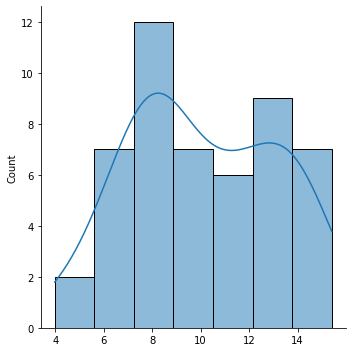

In [58]:
import seaborn as sns
# plot histogram for first column
sns.displot(norm1[:,0],kde=True)

Does this look like a normal distribution? If you were given this dataset, would you say it is 'normally distributed'? What about the second column, let's look at that. Is it normally distributed? 

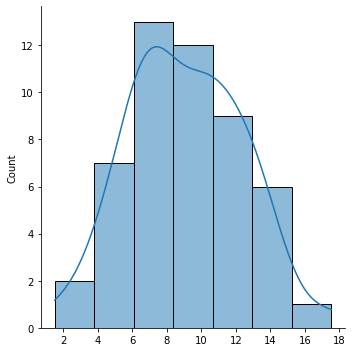

In [59]:
# plot histogram for second column
sns.displot(norm1[:,1],kde=True)

## Random Numbers: Binomial distribution

We can think about other distributions beyond the normal distribution. If we observe a binary variable (yes/no), we might consider that binomially distributed. Here is an example of drawing samples from the binomial distribution:

In [60]:
np.random.seed(42)
# binomial (only one chance of success,probability of success=0.2, 100 samples)
bin1 = np.random.binomial(n=1,p=0.2,size=100)
print(bin1)

[0 1 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 1 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 0 0]


<AxesSubplot:ylabel='count'>

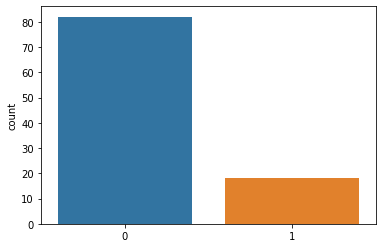

In [61]:
# Plot using countplot from seaborn
sns.countplot(x=bin1)

Here is another example of the binomial distribution with more than one trial. This is the idea that we flip a coin 10 times, and the resulting number is how many 'heads' we observed. 

In [62]:
# binomial (100 "trials,"" probability of success=0.2, 50 samples)
np.random.binomial(n=100,p=0.2,size=50)

array([13, 21, 18, 20, 25, 17, 19, 23, 17, 14, 18, 16, 26, 23, 21, 25, 23, 16, 25, 20,
       23, 25, 18, 15, 17, 19, 24, 24, 11, 20, 19, 17, 15, 18, 26, 18, 20, 22, 19, 28,
       27, 17, 20, 18, 18, 13, 21, 20, 14, 18])

Numpy provides random number generation from other probability distributions such as binomial, poisson, uniform, and many others...   
https://docs.scipy.org/doc/numpy-1.13.0/reference/routines.random.html#distributions

## Concatenation / Conversion

* We may wish to “bind” two arrays
* We may wish to convert an array to a list for use in a different module function which expects a list


In [63]:
# concatenate
bin_ar = np.array(range(5))
ar1 = np.zeros(5)
np.vstack((bin_ar,ar1))

array([[0., 1., 2., 3., 4.],
       [0., 0., 0., 0., 0.]])

In [64]:
# alternatively
bin_ar = bin_ar.reshape((5,1))
ar2 = np.zeros((5,1))
np.hstack((bin_ar,ar2))

array([[0., 0.],
       [1., 0.],
       [2., 0.],
       [3., 0.],
       [4., 0.]])

In [65]:
# The "ravel" function returns a flattened array. Notice how it reduces the dimensionality of this array.
print(bin_ar.shape)
print(bin_ar.ndim)
result = bin_ar.ravel()
print(result.shape)
print(result.ndim)

(5, 1)
2
(5,)
1


## Numpy Iteration

If we treat an ndarray as an iterable, we will be iterating through the rows.

In [66]:
## iteration through columns or rows of ndarray
np.random.seed(12)
ar1 = np.random.poisson(10,6).reshape(3,2)
ar1

array([[ 6,  8],
       [15, 17],
       [ 8, 16]])

In [67]:
for i in ar1:
    print(i)

[6 8]
[15 17]
[ 8 16]


In [68]:
## How would you iterate columns?
for i in ar1.transpose():
    print(i)

[ 6 15  8]
[ 8 17 16]


In [69]:
## More concise
for i in ar1.T:
    print(i)

[ 6 15  8]
[ 8 17 16]


## Saving and loading numpy arrays and csvs

We can save a numpy array to disk with a save function and load it back into memory with a load method.

In [70]:
# Saving a numpy array in the Data folder
np.save('../Data/norm1.npy',norm1)

In [71]:
# Loading it back into memory
nu_data = np.load('../Data/norm1.npy')
print(nu_data.shape)

(50, 2)


You can also load data from a csv directly into a numpy array. Recall that Numpy arrays are typically homogenous (one data type), so this works best for numeric data. We can use Pandas for mixed data types! If there is no missing data, we can use `np.loadtxt()`; if there is missing data, there are numpy methods but perhaps we would do better using Pandas.

In [72]:
np.loadtxt('../Data/health_data/diab_women.csv',delimiter=',')

array([[  6.   , 148.   ,  72.   , ...,   0.627,  50.   ,   1.   ],
       [  1.   ,  85.   ,  66.   , ...,   0.351,  31.   ,   0.   ],
       [  8.   , 183.   ,  64.   , ...,   0.672,  32.   ,   1.   ],
       ...,
       [  5.   , 121.   ,  72.   , ...,   0.245,  30.   ,   0.   ],
       [  1.   , 126.   ,  60.   , ...,   0.349,  47.   ,   1.   ],
       [  1.   ,  93.   ,  70.   , ...,   0.315,  23.   ,   0.   ]])

Similarly we can write an array out in a csv format. 

In [73]:
np.savetxt('../Data/norm1.csv',norm1,delimiter=',')

In [74]:
# uncomment to see the results
# %less ../Data/norm1.csv

## Conclusion

This is a *very* brief introduction to Numpy. Numpy contains many more useful methods and functions, and is leveraged by other scientific packages for its linear algebra, math and stats methods, complex arrays and more. 

Read the chapter on Numpy in your handbook here for more details:

https://jakevdp.github.io/PythonDataScienceHandbook/02.00-introduction-to-numpy.html